# TFM — Análisis Exploratorio de Datos (EDA)

> **Estructura del notebook:**
>
> 0. Setup y carga de datos
> 1. Auditoría de calidad de datos (perfilado tabla a tabla)
> 2. Análisis exploratorio (variable objetivo, demografía, comportamiento)

## 0. Setup y carga de datos

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Rutas
PATH = "../datos/OULAD/"

# Carga de todas las tablas
courses          = pd.read_csv(PATH + "courses.csv")
assessments      = pd.read_csv(PATH + "assessments.csv")
vle              = pd.read_csv(PATH + "vle.csv")
student_info     = pd.read_csv(PATH + "studentInfo.csv")
student_reg      = pd.read_csv(PATH + "studentRegistration.csv")
student_assess   = pd.read_csv(PATH + "studentAssessment.csv")
student_vle      = pd.read_csv(PATH + "studentVle.csv")

print("Carga completada")

Carga completada


## 1. Auditoría de calidad de datos

Realizamos aquí una exploración básica tabla a tabla antes de cualquier análisis con el objetivo de detectar nulos, duplicados, inconsistencias, etc.

### 1.1 courses.csv

In [40]:
# --- Perfil courses.csv ---

print("Shape:", courses.shape)
print("\nDtypes:")
print(courses.dtypes)

print("\nNulos por columna:")
print(courses.isnull().sum())

print("\nUnicidad de la clave (code_module, code_presentation):")
print("Filas totales:", len(courses))
print("Combinaciones únicas:", courses[["code_module", "code_presentation"]].drop_duplicates().shape[0])

print("\nMódulos distintos:", sorted(courses["code_module"].unique()))
print("\nPresentaciones distintas:", sorted(courses["code_presentation"].unique()))

print("\nMatriz módulo x presentación (qué combinaciones existen realmente):")
tabla_existencia = courses.pivot_table(
    index="code_module", columns="code_presentation",
    values="module_presentation_length", aggfunc="count", fill_value=0
)
print(tabla_existencia)

print("\nDescribe de module_presentation_length (duración en días):")
print(courses["module_presentation_length"].describe())

print("\nDuración por módulo (¿varía entre presentaciones del mismo módulo?):")
print(courses.groupby("code_module")["module_presentation_length"].agg(["min", "max", "nunique"]))

Shape: (22, 3)

Dtypes:
code_module                     str
code_presentation               str
module_presentation_length    int64
dtype: object

Nulos por columna:
code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

Unicidad de la clave (code_module, code_presentation):
Filas totales: 22
Combinaciones únicas: 22

Módulos distintos: ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']

Presentaciones distintas: ['2013B', '2013J', '2014B', '2014J']

Matriz módulo x presentación (qué combinaciones existen realmente):
code_presentation  2013B  2013J  2014B  2014J
code_module                                  
AAA                    0      1      0      1
BBB                    1      1      1      1
CCC                    0      0      1      1
DDD                    1      1      1      1
EEE                    0      1      1      1
FFF                    1      1      1      1
GGG                    0      1      1      1

Describe

**Comentarios:**

Como se ve en la matriz de arriba courses tiene 22 combinaciones módulo x presentacion (=semestre) de las 28 posibles. En este caso, la diferencia está en dos módulos que aparecen únicamente en dos semestres de los cuatro posibles que son AAA y CCC, y en otros dos módulos EEE y GGG que aparecen a partir de octubre de 2013, por lo que pierden 2 convocatorias.

De aquí tomamos como referencia la columna 'module_presentation_length', que indica la duración del curso en días, para poder contextualizar nuestra ventana de predicción de 27 días respecto al total del curso.


### 1.2 assessments.csv

In [41]:
# --- Perfil assessments.csv ---

print("Shape:", assessments.shape)
print("\nDtypes:")
print(assessments.dtypes)

print("\nNulos por columna:")
print(assessments.isnull().sum())

print("\nUnicidad de id_assessment como clave:")
print("Filas totales:", len(assessments))
print("id_assessment únicos:", assessments["id_assessment"].nunique())

print("\nassessment_type value_counts:")
print(assessments["assessment_type"].value_counts())

print("\nDescribe de date (día límite de entrega):")
print(assessments["date"].describe())
print("Filas con date negativo:", (assessments["date"] < 0).sum())
print("Filas con date nulo, desglosado por assessment_type:")
print(assessments[assessments["date"].isnull()]["assessment_type"].value_counts())

print("\nDescribe de weight:")
print(assessments["weight"].describe())

print("\nSuma de weight por (code_module, code_presentation), excluyendo Exam:")
suma_pesos = (
    assessments[assessments["assessment_type"] != "Exam"]
    .groupby(["code_module", "code_presentation"])["weight"]
    .sum()
)
print(suma_pesos)
print("\n¿Cuántas combinaciones NO suman 100?:", (suma_pesos.round(1) != 100.0).sum())

print("\nEvaluaciones con date <= 27 (nuestra ventana), por code_module:")
print(assessments[assessments["date"] <= 27].groupby("code_module")["assessment_type"].value_counts())

Shape: (206, 6)

Dtypes:
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

Nulos por columna:
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

Unicidad de id_assessment como clave:
Filas totales: 206
id_assessment únicos: 206

assessment_type value_counts:
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

Describe de date (día límite de entrega):
count    195.000000
mean     145.005128
std       76.001119
min       12.000000
25%       71.000000
50%      152.000000
75%      222.000000
max      261.000000
Name: date, dtype: float64
Filas con date negativo: 0
Filas con date nulo, desglosado por assessment_type:
assessment_type
Exam    11
Name: count, dtype: int64

Describe de weight:
count    206.000000
mean      20.

**Comentarios:**

Aquí encontramos 2026 evaluaciones para los 22 módulos. Los 11 registros nulos en el campo 'date' se corresponden con exámenes finales sin fecha de entrega concreta, si bien ninguno de esos exámenes entra dentro del periodo de 27 días de nuestra ventana de predicción (esto se confirmará más adelante).

Sí es interesante en este punto observar que la columna 'weight' tiene todas las evaluaciones del módulo GGG con una puntuación de 0, lo que quiere decir que las notas de ese módulo no computan para la calificación final del mismo. Esto nos deja ese módulo sin evaluaciones medibles dentro de la ventana de predicción.

In [42]:
# --- Seguimiento: exámenes duplicados y estructura de EEE/GGG ---

# 1. ¿Dónde están los exámenes "de más"?
exams = assessments[assessments["assessment_type"] == "Exam"]
conteo_exam = exams.groupby(["code_module", "code_presentation"]).size().sort_values(ascending=False)
print("Exámenes por presentación (buscamos >1):")
print(conteo_exam)

# 2. Cruce contra las 22 combinaciones reales de courses, por si hay una de más o de menos
combos_courses = courses[["code_module", "code_presentation"]].drop_duplicates()
combos_con_exam = exams[["code_module", "code_presentation"]].drop_duplicates()
print("\nCombinaciones en courses SIN examen asociado:")
print(combos_courses.merge(combos_con_exam, how="left", indicator=True)
      .query('_merge == "left_only"'))
print("\nCombinaciones con examen que NO están en courses:")
print(combos_con_exam.merge(combos_courses, how="left", indicator=True)
      .query('_merge == "left_only"'))

# 3. ¿EEE tiene el mismo problema de weight=0 que GGG, o solo GGG?
print("\nEstructura de assessment_type y weight en EEE y GGG (todas las presentaciones, no solo ventana):")
print(assessments[assessments["code_module"].isin(["EEE", "GGG"])]
      .groupby(["code_module", "assessment_type"])["weight"]
      .agg(["count", "mean", "min", "max"]))

Exámenes por presentación (buscamos >1):
code_module  code_presentation
CCC          2014J                2
             2014B                2
BBB          2013B                1
             2013J                1
AAA          2013J                1
             2014J                1
BBB          2014J                1
             2014B                1
DDD          2013B                1
             2013J                1
             2014B                1
             2014J                1
EEE          2013J                1
             2014B                1
             2014J                1
FFF          2013B                1
             2013J                1
             2014B                1
             2014J                1
GGG          2013J                1
             2014B                1
             2014J                1
dtype: int64

Combinaciones en courses SIN examen asociado:
Empty DataFrame
Columns: [code_module, code_presentation, _merge]
Index: []


**Comentarios:**

Como se vio anteriormente, el conjunto son 22 cursos ¿por qué entonces tenemos 24 exámenes finales? Esta celda responde a esa pregunta y nos muestra que hay un módulo, el CCC, que tiene 2 exámenes por semestre, si bien al quedar los exámenes finales fuera del rango de 0-27 días de la ventana, no nos afecta en el modelado pero sí puede ser un dato a tener en cuenta como nivel de complejidad del módulo.

En el lado contrario EEE y GGG requieren una mirada expresa ya que no tienen evaluaciones de tipo exam en ningún semestre.

In [43]:
print(assessments[(assessments["code_module"] == "CCC") & (assessments["assessment_type"] == "Exam")]
      [["code_presentation", "id_assessment", "date", "weight"]]
      .sort_values(["code_presentation", "date"]))

   code_presentation  id_assessment  date  weight
62             2014B          24290   NaN   100.0
63             2014B          40087   NaN   100.0
72             2014J          24299   NaN   100.0
73             2014J          40088   NaN   100.0


**Comentarios:**

Comprobamos el posible impacto de los dos exámenes de CCC en cada semestre y vemos que tienen peso 100% y fecha nula, por lo que es plausible deducir que se trate de convoctoria ordinaria y extraordinaria, pero confirmamos también que quedan fuera de la ventana y no tienen impacto en el modelo.

### 1.3 vle.csv

In [44]:
# --- Perfil vle.csv ---

print("Shape:", vle.shape)
print("\nDtypes:")
print(vle.dtypes)

print("\nNulos por columna:")
print(vle.isnull().sum())

print("\nUnicidad de (id_site, code_module, code_presentation):")
print("Filas totales:", len(vle))
print("Combinaciones únicas:", vle[["id_site", "code_module", "code_presentation"]].drop_duplicates().shape[0])

print("\n¿Un mismo id_site aparece en más de un code_module distinto? (crítico para el join):")
dup_site = vle.groupby("id_site")["code_module"].nunique()
print((dup_site > 1).sum(), "id_site compartidos entre módulos distintos, de", vle["id_site"].nunique(), "id_site totales")

print("\nactivity_type value_counts:")
print(vle["activity_type"].value_counts())

print("\nweek_from / week_to — dtype real:")
print(vle[["week_from", "week_to"]].dtypes)
print(vle[["week_from", "week_to"]].describe())
print("No nulos en week_from:", vle["week_from"].notnull().sum(), "de", len(vle))

print("\n¿week_from siempre <= week_to?:")
comparables = vle.dropna(subset=["week_from", "week_to"])
print((comparables["week_from"] > comparables["week_to"]).sum(), "filas con week_from > week_to")

print("\n¿Qué activity_type llevan semana informada más a menudo?:")
print(vle.assign(tiene_semana=vle["week_from"].notnull())
      .groupby("activity_type")["tiene_semana"].mean().sort_values(ascending=False))

Shape: (6364, 6)

Dtypes:
id_site                int64
code_module              str
code_presentation        str
activity_type            str
week_from            float64
week_to              float64
dtype: object

Nulos por columna:
id_site                 0
code_module             0
code_presentation       0
activity_type           0
week_from            5243
week_to              5243
dtype: int64

Unicidad de (id_site, code_module, code_presentation):
Filas totales: 6364
Combinaciones únicas: 6364

¿Un mismo id_site aparece en más de un code_module distinto? (crítico para el join):
0 id_site compartidos entre módulos distintos, de 6364 id_site totales

activity_type value_counts:
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage          

**Comentarios:**

Aquí encontramos la clasificación de materiales incluidos en la plataforma, con 6.364 recursos repartidos en los 22 cursos de los 4 semestres.

Un dato útil aquí es que el 82,4% de estos contenidos no cuenta con información del rango de semanas que estuvo disponible en el espacio virtual, por lo que es un campo que debemos descartar como feature.

Otro dato interesante es que se verifica que 'id_site' sirve para identificar el material de manera global, es decir, que no se comparte entre módulos diferentes lo que tendremos que ver si nos ayuda para hacer combinaciones con otras tablas como por ejemplo, 'student_vle' sin tener que inclui 'code_module' como columna de cruce adicional.

### 1.4 studentInfo.csv

In [45]:
# --- Perfil student_info ---

print("Shape:", student_info.shape)
print("\nDtypes:")
print(student_info.dtypes)

print("\nNulos por columna:")
print(student_info.isnull().sum())

print("\nUnicidad de la clave (code_module, code_presentation, id_student):")
print("Filas totales:", len(student_info))
print("Combinaciones únicas:", student_info[["code_module", "code_presentation", "id_student"]].drop_duplicates().shape[0])

print("\nfinal_result value_counts:")
print(student_info["final_result"].value_counts())
print("Nulos en final_result:", student_info["final_result"].isnull().sum())

for col in ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]:
    print(f"\n{col} value_counts:")
    print(student_info[col].value_counts(dropna=False))

print("\nDescribe de num_of_prev_attempts:")
print(student_info["num_of_prev_attempts"].describe())
print("\nDescribe de studied_credits:")
print(student_info["studied_credits"].describe())

print("\n¿Algún id_student con num_of_prev_attempts alto pero solo 1 fila en la tabla? (verificación de coherencia):")
print(student_info[student_info["num_of_prev_attempts"] >= 5][["code_module","code_presentation","id_student","num_of_prev_attempts","final_result"]].head(10))

Shape: (32593, 12)

Dtypes:
code_module               str
code_presentation         str
id_student              int64
gender                    str
region                    str
highest_education         str
imd_band                  str
age_band                  str
num_of_prev_attempts    int64
studied_credits         int64
disability                str
final_result              str
dtype: object

Nulos por columna:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

Unicidad de la clave (code_module, code_presentation, id_student):
Filas totales: 32593
Combinaciones únicas: 32593

final_result value_counts:
final_result
Pass           12361
Withdrawn      10156
Fail            7

**Comentarios:**

Aquí es importante aclarar que la información que muestra la tabla es el equivalente a las matrículas, es decir, que no señala estudiantes únicos, sino que señala los cursos en los que estuvo matriculado un estudiante en cada semestre, de modo, que es posible que un mismo estudiante aparezca varias veces si se matriculó en distintos módulos.

Se confirma que la clave compuesta de tres campos (code_module, code_presentation e id_student) es única, por tanto, no hay duplicados.

En general, la calidad de la información de esta tabla podemos calificarla de muy alta, ya que solo el campo 'imd_band' presenta valores ausentes y es bastante residual (3,4%); en la fase de features habrá que valorar si hay que tratarlos como categoría específica de 'Missings' para evitar perder filas y que el modelo pueda aprender la falta de ese dato.

### 1.5 studentRegistration.csv

In [46]:
print("Shape:", student_reg.shape)
print("\nDtypes:")
print(student_reg.dtypes)

print("\nNulos por columna:")
print(student_reg.isnull().sum())

print("\nUnicidad de la clave (code_module, code_presentation, id_student):")
print("Filas totales:", len(student_reg))
print("Combinaciones únicas:", student_reg[["code_module", "code_presentation", "id_student"]].drop_duplicates().shape[0])

print("\n¿Mismo número de filas que student_info?", len(student_reg) == len(student_info))

print("\nDescribe de date_registration:")
print(student_reg["date_registration"].describe())

print("\nDescribe de date_unregistration:")
print(student_reg["date_unregistration"].describe())
print("Nulos en date_unregistration:", student_reg["date_unregistration"].isnull().sum())

# Cruce con final_result
cruce = student_reg.merge(
    student_info[["code_module", "code_presentation", "id_student", "final_result"]],
    on=["code_module", "code_presentation", "id_student"], how="left"
)
print("\n¿Filas con date_unregistration informado pero final_result != Withdrawn?")
print(len(cruce[cruce["date_unregistration"].notnull() & (cruce["final_result"] != "Withdrawn")]))

print("\n¿Filas con final_result == Withdrawn pero date_unregistration nulo?")
print(len(cruce[(cruce["final_result"] == "Withdrawn") & cruce["date_unregistration"].isnull()]))

print("\nDistribución de date_unregistration alrededor del corte de 27 días (20-35):")
print(student_reg[student_reg["date_unregistration"].between(20, 35)]["date_unregistration"].value_counts().sort_index())

Shape: (32593, 5)

Dtypes:
code_module                str
code_presentation          str
id_student               int64
date_registration      float64
date_unregistration    float64
dtype: object

Nulos por columna:
code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64

Unicidad de la clave (code_module, code_presentation, id_student):
Filas totales: 32593
Combinaciones únicas: 32593

¿Mismo número de filas que student_info? True

Describe de date_registration:
count    32548.000000
mean       -69.411300
std         49.260522
min       -322.000000
25%       -100.000000
50%        -57.000000
75%        -29.000000
max        167.000000
Name: date_registration, dtype: float64

Describe de date_unregistration:
count    10072.000000
mean        49.757645
std         82.460890
min       -365.000000
25%         -2.000000
50%         27.000000
75%        109.000000
max        444.000000
Name

**Comentarios:**

Validamos que la clave es consistente entre tablas, puesto que coincide exactamente con el número de matrículas que obteníamos en 'student_info'.

La buena noticia es que el 69,1% de los estudiantes (22.521) no tiene fecha de baja, por lo que podemos determinar que terminaron el curso o siguieron activos.

Existe un grupo muy residual que apenas llega al 0,1% (45 matrículas) que no tienen fecha de registro, previsiblemente se desestimará acción alguna de tratamiento más adelante por volumen mínimo. Se observa también que la media de inscripción es de 69 días antes de comenzar el módulo, algo más de dos meses.

In [47]:
# 1. Filas con date_unregistration pero final_result != Withdrawn
print("Casos con date_unregistration informado pero final_result != Withdrawn:")
print(cruce[cruce["date_unregistration"].notnull() & (cruce["final_result"] != "Withdrawn")]
      [["code_module", "code_presentation", "id_student", "date_unregistration", "final_result"]])

# 2. Los 93 Withdrawn sin date_unregistration
withdrawn_sin_fecha = cruce[(cruce["final_result"] == "Withdrawn") & cruce["date_unregistration"].isnull()]
print("\n93 Withdrawn sin date_unregistration, por módulo-presentación:")
print(withdrawn_sin_fecha.groupby(["code_module", "code_presentation"]).size())
# Nota: el cross-check de actividad VLE de estos 93 está en sección 2.5
# (requiere vle_ventana, que se define allí)

# 3. ¿El pico en día 27 está concentrado en algún módulo/presentación?
print("\nUnregistrations en día exacto 27, por módulo-presentación:")
print(student_reg[student_reg["date_unregistration"] == 27]
      .groupby(["code_module", "code_presentation"]).size().sort_values(ascending=False))

# 4. Registros más tardíos
print("\nRegistros más tardíos (date_registration más alto):")
print(cruce.sort_values("date_registration", ascending=False)
      [["code_module", "code_presentation", "id_student", "date_registration", "final_result"]].head(10))


Casos con date_unregistration informado pero final_result != Withdrawn:
      code_module code_presentation  id_student  date_unregistration  \
2777          BBB             2013J      362907                  0.0   
2786          BBB             2013J      365288                  0.0   
3340          BBB             2013J      554243                166.0   
14625         DDD             2013J      315082                  0.0   
14768         DDD             2013J      403052                  0.0   
15577         DDD             2013J      582954                 -7.0   
24057         FFF             2013J      234004                  0.0   
24537         FFF             2013J      523777                  0.0   
25685         FFF             2013J      601640                 -4.0   

      final_result  
2777          Fail  
2786          Fail  
3340          Fail  
14625         Fail  
14768         Fail  
15577         Fail  
24057         Fail  
24537         Fail  
25685         Fail

**Comentarios:**

En estas consultas concretas, vemos un par de inconsistencias de baja impacto en los datos de registro:

Por un lado, hay 9 filas con fecha de baja pero con resultado 'Fail' (en lugar de 'Withdrawn'). Se trata de situaciones en las que el alumno completó el proceso de evaluación con resultado negativo pero el sistema registró una baja por algún motivo.

Por otro lado, existen 93 registros con resultado 'Withdrawn', que no tienen fecha de baja. Dentro de este grupo, 87 pertenecen a módulos del semestre 2014J, lo que concentra una anomalía de calidad que tendremos que tratar llegado el momento.

### 1.6 studentAssessment.csv

In [48]:
# --- Perfil student_assess ---

print("Shape:", student_assess.shape)
print("\nDtypes:")
print(student_assess.dtypes)

print("\nNulos por columna:")
print(student_assess.isnull().sum())

print("\nUnicidad de (id_assessment, id_student):")
print("Filas totales:", len(student_assess))
print("Combinaciones únicas:", student_assess[["id_assessment", "id_student"]].drop_duplicates().shape[0])

print("\nis_banked value_counts:")
print(student_assess["is_banked"].value_counts())

print("\nDescribe de score:")
print(student_assess["score"].describe())
print("Scores fuera de rango [0,100]:", ((student_assess["score"] < 0) | (student_assess["score"] > 100)).sum())

print("\nDescribe de date_submitted:")
print(student_assess["date_submitted"].describe())
print("Entregas con date_submitted negativo:", (student_assess["date_submitted"] < 0).sum())

print("\n¿id_assessment de student_assess que NO existen en assessments.csv? (integridad del join):")
ids_validos = set(assessments["id_assessment"])
huerfanos = student_assess[~student_assess["id_assessment"].isin(ids_validos)]
print(len(huerfanos), "filas huérfanas")

print("\n¿Algún id_student con más de una entrega para el mismo id_assessment?")
dup = student_assess.groupby(["id_assessment", "id_student"]).size()
print((dup > 1).sum(), "combinaciones con más de una entrega")

Shape: (173912, 5)

Dtypes:
id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object

Nulos por columna:
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

Unicidad de (id_assessment, id_student):
Filas totales: 173912
Combinaciones únicas: 173912

is_banked value_counts:
is_banked
0    172003
1      1909
Name: count, dtype: int64

Describe de score:
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64
Scores fuera de rango [0,100]: 0

Describe de date_submitted:
count    173912.000000
mean        116.032942
std          71.484148
min         -11.000000
25%          51.000000
50%         116.000000
75%         173.000000
max         608.000000
Name: date_submitted, dtype: 

**Comentarios:**

Contamos aquí 173.912 entregas evaluables, con dos focos de atención claros:

- 173 puntuaciones nulas de tipo TMA repartidas en varios semestres. Aunque es un volumen pequeño, apenas un 0,1% del total de entregas, tendremos que revisar en otro punto cuantos de esos nulos están dentro de nuestra ventana de predicción.
- 1909 entregas importadas: se trata de notas importadas de semestres anteriores, por lo que no representan nuevas acciones del alumno. A valorar tratamiento en fases posteriores.

In [49]:
print("date_submitted negativo, cruzado con is_banked:")
print(student_assess[student_assess["date_submitted"] < 0]["is_banked"].value_counts())

print("\nEntregas con date_submitted negativo Y is_banked=0 (no cubiertas por el filtro actual):")
negativas_no_banked = student_assess[(student_assess["date_submitted"] < 0) & (student_assess["is_banked"] == 0)]
print(len(negativas_no_banked))
print(negativas_no_banked.head(10))

print("\nFilas con score nulo, tipo de evaluación asociado:")
nulos_score = student_assess[student_assess["score"].isnull()].merge(
    assessments[["id_assessment", "assessment_type"]], on="id_assessment", how="left"
)
print(nulos_score["assessment_type"].value_counts())

date_submitted negativo, cruzado con is_banked:
is_banked
1    1909
0     148
Name: count, dtype: int64

Entregas con date_submitted negativo Y is_banked=0 (no cubiertas por el filtro actual):
148
       id_assessment  id_student  date_submitted  is_banked  score
3309           14984       84245              -4          0   82.0
3349           14984      169515              -5          0   70.0
3550           14984      418325              -3          0   75.0
3897           14984      528698              -4          0   76.0
3906           14984      530065              -3          0   49.0
4048           14984      541231              -6          0   68.0
15345          14996      582878              -4          0   75.0
15453          14996      590231              -2          0   68.0
15866          14996      610700              -9          0   75.0
16010          14996     2211630              -2          0   65.0

Filas con score nulo, tipo de evaluación asociado:
assessment_typ

**Comentarios:**

Continuando con la consulta, vemos que las entregas con fecha negativa coinciden con el dato que vimos en la celda anterior de 1909 entregas importadas, por lo que esto nos confirma que fueron registradas antes del inicio oficial del curso.

Por otro lado, existen 148 entregas con fecha negativa pero que no han sido importadas, al tener registrada una fecha antes del inicio, quedan directamente fuera de la ventana de 0 a 27 días, por lo que queda directamente descartado el tratamiento.

In [50]:
print("Score nulo, TMA, dentro de la ventana (date_submitted<=27) y no importadas:")
nulos_en_ventana = nulos_score[(nulos_score["date_submitted"] <= 27) & (nulos_score["is_banked"] == 0)]
print(len(nulos_en_ventana))
print(nulos_en_ventana[["id_assessment", "id_student", "date_submitted", "is_banked", "score"]])

Score nulo, TMA, dentro de la ventana (date_submitted<=27) y no importadas:
17
     id_assessment  id_student  date_submitted  is_banked  score
0             1752      721259              22          0    NaN
4            14984      531205              26          0    NaN
5            14984      534151               7          0    NaN
29           15008      606501              11          0    NaN
46           15020      654422              18          0    NaN
47           15020      678578              19          0    NaN
67           25334      168243              23          0    NaN
68           25334      235428              25          0    NaN
69           25334      555297              -2          0    NaN
85           25348      427248              25          0    NaN
124          34860      174436              13          0    NaN
128          34860      546164              22          0    NaN
139          34873      126074              20          0    NaN
149        

**Comentarios:**

Aquí hacemos la comprobación indicada previamente para asegurarnos de cuántas de esas 173 entregas nulas están dentro de nuestra ventana de predicción; el resultado es aún más residual: solo 17 entran dentro de la ventana de predicción. Se deja documentado, aunque por el alcance, se prevé descartar tratamiento específico en el featuring.

### 1.7 studentVle.csv

In [51]:
# --- Perfil student_vle ---

print("Shape:", student_vle.shape)
print("\nDtypes:")
print(student_vle.dtypes)

print("\nNulos por columna:")
print(student_vle.isnull().sum())

print("\nUnicidad de (code_module, code_presentation, id_student, id_site, date):")
print("Filas totales:", len(student_vle))
print("Combinaciones únicas:", student_vle[["code_module", "code_presentation", "id_student", "id_site", "date"]].drop_duplicates().shape[0])

print("\nDescribe de sum_click:")
print(student_vle["sum_click"].describe())
print("Filas con sum_click <= 0:", (student_vle["sum_click"] <= 0).sum())

print("\nDescribe de date:")
print(student_vle["date"].describe())

print("\n¿id_site en student_vle que NO existen en vle.csv? (integridad del join):")
ids_vle_validos = set(vle["id_site"])
huerfanos_site = (~student_vle["id_site"].isin(ids_vle_validos)).sum()
print(huerfanos_site, "filas huérfanas")

print("\n¿(id_student, code_module, code_presentation) en student_vle que NO existen en student_info?")
claves_validas = set(map(tuple, student_info[["code_module", "code_presentation", "id_student"]].values))
claves_vle = list(map(tuple, student_vle[["code_module", "code_presentation", "id_student"]].drop_duplicates().values))
huerfanos_estudiante = sum(1 for c in claves_vle if c not in claves_validas)
print(huerfanos_estudiante, "combinaciones estudiante-módulo-presentación sin match en student_info")

Shape: (10655280, 6)

Dtypes:
code_module            str
code_presentation      str
id_student           int64
id_site              int64
date                 int64
sum_click            int64
dtype: object

Nulos por columna:
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64

Unicidad de (code_module, code_presentation, id_student, id_site, date):
Filas totales: 10655280
Combinaciones únicas: 8459320

Describe de sum_click:
count    1.065528e+07
mean     3.716946e+00
std      8.849047e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      6.977000e+03
Name: sum_click, dtype: float64
Filas con sum_click <= 0: 0

Describe de date:
count    1.065528e+07
mean     9.517400e+01
std      7.607130e+01
min     -2.500000e+01
25%      2.500000e+01
50%      8.600000e+01
75%      1.560000e+02
max      2.690000e+02
Name: date, dtype: float64

¿id_site en 

**Comentarios:**

Aquí llegamos a la tabla más grande del dataset con 10.655.280 registros de actividad y ningún nulo entre ellos. Esto nos da la información de los clics de un alumno en una fecha concreta y un contenido concreto.

Cabe señalar que si bien el rango total de registros toma desde 25 días antes del inicio del módulo a 269 días (con margen posterior suficiente para los módulos más cortos), como ya se ha indicado nuestra ventana de predicción se basará en el periodo del día 0 al 27, lo que le dará al modelo un volumen de apróximadamente 2,8 millones de filas para aprender, el 26,3%.

In [52]:
dup_mask = student_vle.duplicated(
    subset=["code_module", "code_presentation", "id_student", "id_site", "date"], keep=False
)
duplicados = student_vle[dup_mask]
print("Filas implicadas en claves duplicadas:", len(duplicados))

exact_dups = student_vle.duplicated(keep=False)
print("Filas EXACTAMENTE duplicadas (las 6 columnas iguales):", exact_dups.sum())

print("\nEjemplo de claves con más repeticiones:")
print(duplicados.groupby(["code_module", "code_presentation", "id_student", "id_site", "date"])
      .size().sort_values(ascending=False).head(5))

Filas implicadas en claves duplicadas: 3810465
Filas EXACTAMENTE duplicadas (las 6 columnas iguales): 1429783

Ejemplo de claves con más repeticiones:
code_module  code_presentation  id_student  id_site  date
EEE          2013J              2569834     551072   156     10
             2014J              654397      973720   157     10
             2014B              2577893     790866   143     10
             2014J              525625      973720   165     10
                                650770      973720   157     10
dtype: int64


**Comentarios:**

Si bien la no aparición de nulos era una buena noticia en la celda anterior, en esta se han destapado dos líneas diferentes de duplicidad:

- Por un lado, tenemos casi cuatro millones de filas con la misma clave de 5 columnas (3.810.465). Esto en la práctica se traduce en que tienen el mismo módulo, semestre, alumno, contenido y día pero tienen sumas de clics distintos. Se deben entender como sesiones de estudio legítimas y diferentes. 
- Por otro lado, hay 1.429.783 filas con las 6 columnas exactamente igual, lo que sí es una duplicidad real del sistema. El matiz es que este conteo usa 'keep=False', que marca como duplicada toda fila que pertenece a un grupo con copia, es decir,que incluye la que se terminará conservando, no solo las copias de más. Anotamos esto como matiz para las features.

En ambos casos, tendremos que ver su tratamiento en la siguiente fase del proceso.

## 2. Análisis exploratorio

### 2.1 Visión general del dataset

In [53]:
tablas = {
    "courses":        courses,
    "assessments":    assessments,
    "vle":            vle,
    "student_info":   student_info,
    "student_reg":    student_reg,
    "student_assess": student_assess,
    "student_vle":    student_vle,
}

for nombre, df in tablas.items():
    print(f"\n{'='*40}")
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(df.dtypes)


courses: 22 filas × 3 columnas
code_module                     str
code_presentation               str
module_presentation_length    int64
dtype: object

assessments: 206 filas × 6 columnas
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

vle: 6,364 filas × 6 columnas
id_site                int64
code_module              str
code_presentation        str
activity_type            str
week_from            float64
week_to              float64
dtype: object

student_info: 32,593 filas × 12 columnas
code_module               str
code_presentation         str
id_student              int64
gender                    str
region                    str
highest_education         str
imd_band                  str
age_band                  str
num_of_prev_attempts    int64
studied_credits         int64
disability                str
final_result              str


In [54]:
# Módulos y presentaciones disponibles
print("COURSES:")
print(courses.sort_values(["code_module", "code_presentation"]).to_string(index=False))

# Distribución de la variable objetivo
print("\nFINAL_RESULT (valores absolutos y porcentaje):")
counts = student_info["final_result"].value_counts()
pct    = student_info["final_result"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"n": counts, "%": pct}))

COURSES:
code_module code_presentation  module_presentation_length
        AAA             2013J                         268
        AAA             2014J                         269
        BBB             2013B                         240
        BBB             2013J                         268
        BBB             2014B                         234
        BBB             2014J                         262
        CCC             2014B                         241
        CCC             2014J                         269
        DDD             2013B                         240
        DDD             2013J                         261
        DDD             2014B                         241
        DDD             2014J                         262
        EEE             2013J                         268
        EEE             2014B                         241
        EEE             2014J                         269
        FFF             2013B                         240
     

**Comentarios:**

Aunque ya en la fase de auditoría de calidad de los datos se ha realizado un análisis de cada tabla viendo sus datos básicos y algunas dudas que era bueno tener claras desde el inicio, aquí vamos a realizar una consolidación de dataset, unificando en un solo lugar todas las tablas y sus campos correspondientes.

Queda establecida aquí la 'matrícula' como unidad de análisis y se compone de tres datos inequívocos: alumno + módulo + semestre. De este modo, asumimos que un mismo estudiante puede tener varias matrículas, aunque estas no podrán repetirse entre sí.

Vemos también en esta exploración que trabajamos con 7 módulos en hasta 4 presentaciones (= semestres).

Por su parte, la variable 'final_result' parece la idónea para convertirse en nuestra variable objetivo ya que nos da exactamente el dato que responde a nuestra pregunta esencial del modelo ¿está este estudiante en riesgo? Si que hay que señalar aquí que las tasas de riesgo son asimétricas entre semestres, lo que da pie al split cronológico Train / Test que se planteará más adelante.

### 2.2 Variable objetivo

In [55]:
# Crear variable binaria de riesgo
student_info["riesgo"] = student_info["final_result"].isin(["Fail", "Withdrawn"]).astype(int)

# Verificar distribución
print("Variable riesgo:")
print(student_info["riesgo"].value_counts())
print(f"\nTotal filas: {len(student_info):,}")
print(f"Riesgo=1: {student_info['riesgo'].sum():,} ({student_info['riesgo'].mean()*100:.1f}%)")
print(f"Riesgo=0: {(1-student_info['riesgo']).sum():,} ({(1-student_info['riesgo']).mean()*100:.1f}%)")

Variable riesgo:
riesgo
1    17208
0    15385
Name: count, dtype: int64

Total filas: 32,593
Riesgo=1: 17,208 (52.8%)
Riesgo=0: 15,385 (47.2%)


**Comentarios:**

Tenemos clara aquí la variable objetivo que será 'riesgo'; riesgo = 1 si el final_result es Fail o Withdrawn y riesgo = 0 si es Pass o Distinction.

Para no perder la perspectiva, en la población total de 32.593 matrículas, el balance es de riesgo = 1 en el 52,8% y riesgo = 0 en el 47,2%, por lo que hay una ligera tendencia positiva al riesgo. También es importante anotar, que acotándolo a la ventana de predicción de 0 a 27 días, este balance se inclina al lado contrario, 44,2% riesgo = 1 y 55,8% riesgo = 0, que es lo que va a ser la referencia real del modelo.

In [56]:
# Riesgo por módulo
print("RIESGO POR MÓDULO:")
riesgo_modulo = student_info.groupby("code_module")["riesgo"].agg(
    n="count",
    riesgo_n="sum"
)
riesgo_modulo["riesgo_%"] = (riesgo_modulo["riesgo_n"] / riesgo_modulo["n"] * 100).round(1)
print(riesgo_modulo.sort_values("riesgo_%", ascending=False))

# Riesgo por presentación
print("\nRIESGO POR PRESENTACIÓN (cronológico):")
orden = ["2013B", "2013J", "2014B", "2014J"]
riesgo_pres = student_info.groupby("code_presentation")["riesgo"].agg(
    n="count",
    riesgo_n="sum"
)
riesgo_pres["riesgo_%"] = (riesgo_pres["riesgo_n"] / riesgo_pres["n"] * 100).round(1)
print(riesgo_pres.reindex(orden))

RIESGO POR MÓDULO:
                n  riesgo_n  riesgo_%
code_module                          
CCC          4434      2756      62.2
DDD          6272      3662      58.4
FFF          7762      4114      53.0
BBB          7909      4155      52.5
EEE          2934      1284      43.8
GGG          2534      1020      40.3
AAA           748       217      29.0

RIESGO POR PRESENTACIÓN (cronológico):
                       n  riesgo_n  riesgo_%
code_presentation                           
2013B               4684      2589      55.3
2013J               8845      4370      49.4
2014B               7804      4446      57.0
2014J              11260      5803      51.5


**Comentarios:**

En esta parte del análisis vemos un dato bastante llamativo y es que la tasa de riesgo varia 33 puntos porcentuales entre el más bajo (AAA y el más alto CCC); también hay una tendencia en los semestres, donde parece que los segundos semestres del año (indicados con la J) tienen porcentajes de riesgo más bajos. De todo esto sale una conclusión interesante y es que un alumno con el mismo comportamiento en diferente módulos podría derivar en señales de riesgo diferentes.

A la vista de estos datos, dejamos ya aquí documentada una decisión de diseño se extenderá a las fases posteriores: la variable 'code_module' debe ser excluida del modelo final para facilitar que este pueda generalizar a módulos no vistos en el entrenamiento; asumo aquí que perdemos el riesgo base diferencial pero ganamos la escalabilidad del modelo.

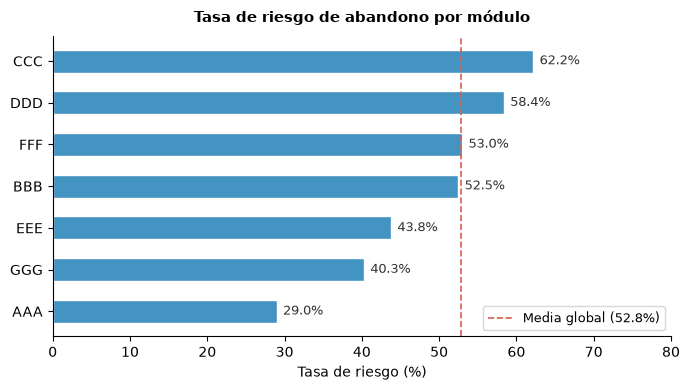

Guardado en ../datos/grafico_riesgo_modulo.png


In [57]:
# riesgo_modulo ya calculado arriba
rm = riesgo_modulo.sort_values("riesgo_%", ascending=True)  # ascendente para que el mayor quede arriba en horizontal

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.barh(rm.index, rm["riesgo_%"], color='#4393c3', edgecolor='white', height=0.55)

# Etiquetas de valor
for bar, val in zip(bars, rm["riesgo_%"]):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9, color='#333333')

# Línea de media global
media_global = student_info["riesgo"].mean() * 100
ax.axvline(media_global, color='#d6604d', linestyle='--', linewidth=1.2,
           label=f'Media global ({media_global:.1f}%)')

ax.set_xlabel('Tasa de riesgo (%)', fontsize=10)
ax.set_xlim(0, 80)
ax.set_title('Tasa de riesgo de abandono por módulo', fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('../datos/grafico_riesgo_modulo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado en ../datos/grafico_riesgo_modulo.png")

**Comentarios:**

Materializamos los datos de la celda anterior en una gráfica donde de un vistazo podemos observar dónde se encuentra la media global de abandono (población completa) y como queda situada en cada módulo.

### 2.3 Perfil demográfico

In [58]:
print("MISSINGS EN STUDENT_INFO:")
missings = student_info.isnull().sum()
missings_pct = (missings / len(student_info) * 100).round(1)
print(pd.DataFrame({"nulos": missings, "%": missings_pct})[missings > 0])

print("\nValores únicos por columna categórica:")
cats = ["gender", "region", "highest_education", "imd_band", "age_band", "disability", "final_result"]
for col in cats:
    print(f"\n{col}: {student_info[col].nunique()} valores únicos")
    print(student_info[col].value_counts().to_string())

MISSINGS EN STUDENT_INFO:
          nulos    %
imd_band   1111  3.4

Valores únicos por columna categórica:

gender: 2 valores únicos
gender
M    17875
F    14718

region: 13 valores únicos
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184

highest_education: 5 valores únicos
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313

imd_band: 10 valores únicos
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-1

**Comentarios:**

En general, la calidad de los datos demográficos es buena ya que tan solo una variable, 'imd_band', recoge valores nulos, el resto de variables categóricas están correctamente informadas.

Resumen de los datos:

- gender: 9 puntos de diferencia para la mayoría masculina.
- region: se observa una distribución desigual, en la que Escocia, East Anglian y Londres encabezan la lista de las más representadas.
- highest_education: hay dos resultados que aglutinan al 83,5% de los alumnos.
- imd_band: bastante uniforme a pesar de los valores nulos ya mencionados

In [59]:
# Corregir el valor inconsistente
student_info["imd_band"] = student_info["imd_band"].replace("10-20", "10-20%")

# Rellenar missings con categoría explícita
student_info["imd_band"] = student_info["imd_band"].fillna("Missing")

# Verificar que queda limpio
print("imd_band tras corrección:")
print(student_info["imd_band"].value_counts().sort_index())
print(f"\nMissings restantes: {student_info['imd_band'].isnull().sum()}")

imd_band tras corrección:
imd_band
0-10%      3311
10-20%     3516
20-30%     3654
30-40%     3539
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Missing    1111
Name: count, dtype: int64

Missings restantes: 0


**Comentarios:**

Corrijo aquí un valor que he detectado en la vista previa que no sigue la pauta del resto, "10-20" sin el símbolo de porcentaje y aprovecha ya para recategorizar en su variable explícita de "Missing" los valores nulos mencionados arriba. El motivo de esta decisión es que permite que el modelo aprenda si la falta del dato socioeconómico tiene valor predictivo por sí misma.

In [60]:
# Tasa de riesgo por cada variable demográfica
demo_vars = ["gender", "highest_education", "imd_band", "age_band", "disability", "num_of_prev_attempts"]

for var in demo_vars:
    print(f"\n{'='*45}")
    print(f"RIESGO POR {var.upper()}:")
    tabla = student_info.groupby(var)["riesgo"].agg(n="count", riesgo_pct=lambda x: round(x.mean()*100, 1))
    print(tabla.sort_values("riesgo_pct", ascending=False).to_string())


RIESGO POR GENDER:
            n  riesgo_pct
gender                   
M       17875        53.8
F       14718        51.6

RIESGO POR HIGHEST_EDUCATION:
                                 n  riesgo_pct
highest_education                             
No Formal quals                347        70.3
Lower Than A Level           13158        61.1
A Level or Equivalent        14045        48.0
HE Qualification              4730        43.8
Post Graduate Qualification    313        34.5

RIESGO POR IMD_BAND:
             n  riesgo_pct
imd_band                  
0-10%     3311        64.8
10-20%    3516        61.4
20-30%    3654        59.3
40-50%    3256        53.4
30-40%    3539        53.1
50-60%    3124        51.2
70-80%    2879        48.5
60-70%    2905        48.1
80-90%    2762        45.9
90-100%   2536        42.5
Missing   1111        34.3

RIESGO POR AGE_BAND:
              n  riesgo_pct
age_band                   
0-35      22944        55.0
35-55      9433        47.8
55<=     

**Comentarios:**

En esta celda obtenemos resultados bastante potentes respecto a la capacidad selectiva de las variables demográficas:

- 'highest_education': se trata de la variable predictora más fuerte en este bloque, donde se muestra un descenso del riesgo de hasta 36 puntos porcentuales entre la categoría de "Sin formación formal" (70,3%) y la de "Postgrado" (34,5%).
- 'imd_band': aquí podemos ver un dato llamativo y es que el grupo de "Missing" presenta el riesgo más bajo (29,1%), lo que puede derivar en una correlación entre la falta del dato y perfiles de regiones o contextos con mejor rendimiento promedio.
- 'disability': parece que la discapacidad supone un factor que incrementa el riesgo de abandono en apróximadamente 10 puntos.

### 2.4 Bajas y filtro de activos

Aquí aplicamos el filtro ya mencionado de nuestra ventana de predicción, por lo que excluimos estudiantes con 'date_unregistration =< 27' que son quienes ya se habían ido antes de que termine la ventana de predicción, no son predecibles en producción.

In [61]:
print("STUDENT_REGISTRATION — estadísticos básicos:")
print(student_reg[["date_registration", "date_unregistration"]].describe().round(1))

print(f"\nEstudiantes con baja registrada: {student_reg['date_unregistration'].notna().sum():,}")
print(f"Porcentaje con baja: {student_reg['date_unregistration'].notna().mean()*100:.1f}%")

# Distribución de bajas respecto a la ventana de predicción (día 27)
bajas = student_reg[student_reg["date_unregistration"].notna()].copy()
bajas_antes_27 = (bajas["date_unregistration"] <= 27).sum()
print(f"\nBajas antes del día 27 (dentro de nuestra ventana): {bajas_antes_27:,}")
print(f"Bajas en día 27 o después: {(bajas['date_unregistration'] > 27).sum():,}")

STUDENT_REGISTRATION — estadísticos básicos:
       date_registration  date_unregistration
count            32548.0              10072.0
mean               -69.4                 49.8
std                 49.3                 82.5
min               -322.0               -365.0
25%               -100.0                 -2.0
50%                -57.0                 27.0
75%                -29.0                109.0
max                167.0                444.0

Estudiantes con baja registrada: 10,072
Porcentaje con baja: 30.9%

Bajas antes del día 27 (dentro de nuestra ventana): 5,040
Bajas en día 27 o después: 5,032


**Comentarios:**

La media de la inscripción se sitúa en 69 días antes del comienzo del curso, lo que muestra bastante antelación en esa matriculación. 

Tenemos un porcentaja de bajas registradas del 30,9%, de  los cuales el 50% la cursó en los primeros 27 días, lo cual tiene sentido con prácticas habituales en las escuelas/universidades, donde hay un plazo al inicio para desistir y recuperar toda o parte de la inversión. De cara a nuestro modelo, influye en que esos registros quedan fuera del modelado => 5.040.

In [62]:
# Unir student_info con student_reg para tener date_unregistration
df = student_info.merge(
    student_reg[["id_student", "code_module", "code_presentation", "date_unregistration"]],
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

# Filtro: activos al final del día 27
# (nunca se dieron de baja, o se dieron de baja después del día 27)
df_activos = df[(df["date_unregistration"].isna()) | (df["date_unregistration"] > 27)].copy()

print(f"Estudiantes totales:          {len(df):,}")
print(f"Estudiantes activos en día 27: {len(df_activos):,}")
print(f"Excluidos (baja <= día 27):    {len(df) - len(df_activos):,}")

print(f"\nBalance de clases tras filtro:")
print(f"Riesgo=1: {df_activos['riesgo'].sum():,} ({df_activos['riesgo'].mean()*100:.1f}%)")
print(f"Riesgo=0: {(1-df_activos['riesgo']).sum():,} ({(1-df_activos['riesgo']).mean()*100:.1f}%)")

print(f"\nDesglose del riesgo=1 restante por final_result:")
print(df_activos[df_activos["riesgo"]==1]["final_result"].value_counts())

Estudiantes totales:          32,593
Estudiantes activos en día 27: 27,553
Excluidos (baja <= día 27):    5,040

Balance de clases tras filtro:
Riesgo=1: 12,168 (44.2%)
Riesgo=0: 15,385 (55.8%)

Desglose del riesgo=1 restante por final_result:
final_result
Fail         7044
Withdrawn    5124
Name: count, dtype: int64


**Comentarios:**

En esta celda aplicamos el filtro de activos, retirando los 5.040 mencionados antes que cursaron baja antes del día 27 de cada presentación (semestre). Con esto hecho, recalculamos el riesgo y vemos la inversión de las tendencias, una vez descartados las bajas iniciales, el riesgo cae al 44,2%.

Como se puede observar el desglose del riesgo = 1 restante queda en 7.044 Fail + 5.124 Withdrawn, que son estudiantes activos que no superan el módulo no sin baja antes de que finalice nuestra ventana de predicción.

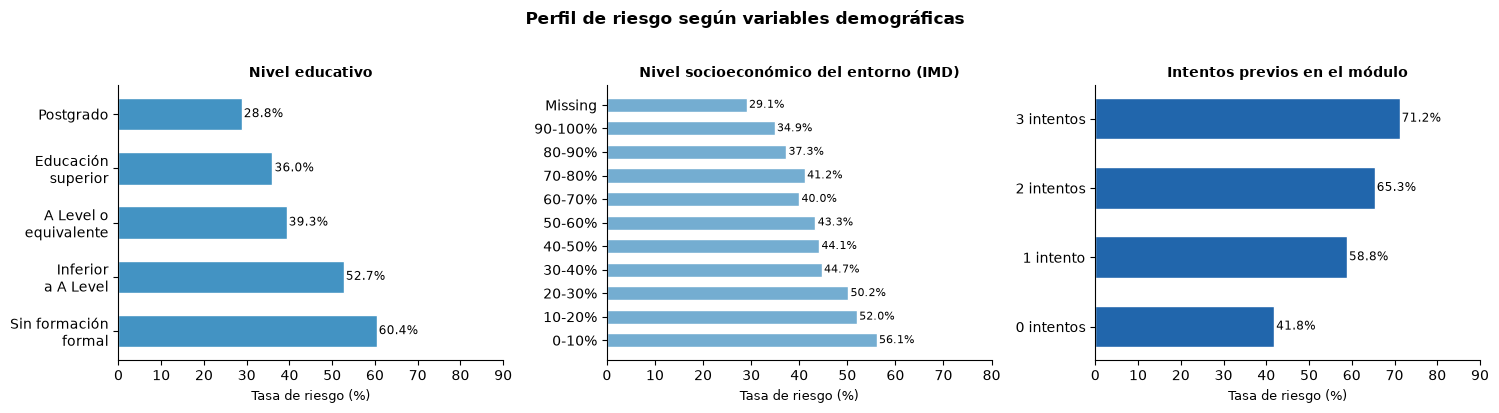

Guardado en ../datos/grafico_demograficas.png


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Subplot 1: highest_education ---
orden_edu = ["No Formal quals", "Lower Than A Level", "A Level or Equivalent",
             "HE Qualification", "Post Graduate Qualification"]
etiquetas_edu = ["Sin formación\nformal", "Inferior\na A Level", "A Level o\nequivalente",
                 "Educación\nsuperior", "Postgrado"]

tabla_edu = (df_activos.groupby("highest_education")["riesgo"]
             .mean() * 100).reindex(orden_edu)

axes[0].barh(etiquetas_edu, tabla_edu.values, color='#4393c3', edgecolor='white', height=0.6)
for i, val in enumerate(tabla_edu.values):
    axes[0].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[0].set_xlim(0, 90)
axes[0].set_title('Nivel educativo', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Tasa de riesgo (%)', fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Subplot 2: imd_band ---
orden_imd = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
             "50-60%", "60-70%", "70-80%", "80-90%", "90-100%", "Missing"]

tabla_imd = (df_activos.groupby("imd_band")["riesgo"]
             .mean() * 100).reindex(orden_imd).dropna()

axes[1].barh(tabla_imd.index, tabla_imd.values, color='#74add1', edgecolor='white', height=0.6)
for i, val in enumerate(tabla_imd.values):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8)
axes[1].set_xlim(0, 80)
axes[1].set_title('Nivel socioeconómico del entorno (IMD)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Tasa de riesgo (%)', fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# --- Subplot 3: num_of_prev_attempts (solo 0-3, muestra suficiente) ---
tabla_prev = (df_activos[df_activos["num_of_prev_attempts"] <= 3]
              .groupby("num_of_prev_attempts")["riesgo"]
              .mean() * 100)

etiquetas_prev = [f'{i} intento{"s" if i != 1 else ""}' for i in tabla_prev.index]
axes[2].barh(etiquetas_prev, tabla_prev.values, color='#2166ac', edgecolor='white', height=0.6)
for i, val in enumerate(tabla_prev.values):
    axes[2].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[2].set_xlim(0, 90)
axes[2].set_title('Intentos previos en el módulo', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Tasa de riesgo (%)', fontsize=9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('Perfil de riesgo según variables demográficas', fontsize=12,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../datos/grafico_demograficas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado en ../datos/grafico_demograficas.png")

**Comentarios:**

Exploramos visualmente los tres predictores demográficos más potentes sobre la población activa (filtrada), destacando aquí:

- 'highest_education': gradiente decreciente de riesgo con el nivel educativo.
- 'imd_band': disminución del riesgo en entornos socioeconómicos con mayor rango.
- 'num_of_prev_attempts': el número de intentos previos (hasta 3) incrementa el riesgo.

In [64]:
# ¿Cuántos estudiantes activos tienen date_registration > 27?
tarde = cruce[cruce["date_registration"] > 27]
print(f"Inscritos después del día 27 (total, sin filtro de bajas): {len(tarde):,}")

Inscritos después del día 27 (total, sin filtro de bajas): 18


**Comentarios:**

Claramente el plazo de inscripción de los módulos vence a las 4 semanas de comienzo, por ese motivo, tan solo encontramos 18 matrículas, que podemos atribuir a excepciones o reservas formalizadas tardías.

#### Distribución de 'num_of_prev_attempts' en población activa

In [65]:
print("value_counts de num_of_prev_attempts (activos):")
print(df_activos["num_of_prev_attempts"].value_counts().sort_index())

print("\nRiesgo medio por num_of_prev_attempts, con tamaño de muestra (activos):")
print(df_activos.groupby("num_of_prev_attempts")["riesgo"].agg(["mean", "count"]))

value_counts de num_of_prev_attempts (activos):
num_of_prev_attempts
0    24073
1     2770
2      554
3      111
4       31
5       11
6        3
Name: count, dtype: int64

Riesgo medio por num_of_prev_attempts, con tamaño de muestra (activos):
                          mean  count
num_of_prev_attempts                 
0                     0.418228  24073
1                     0.588448   2770
2                     0.653430    554
3                     0.711712    111
4                     0.580645     31
5                     0.818182     11
6                     0.666667      3


**Comentarios:**

Revisamos aquí lo que ocurre con todos los intentos previos y se confirma lo que ya se mostraba en la gráfica anterior, hay una tendencia de riesgo positivo directamente proporcional a más intentos más riesgo, pero observamos que a partir del 4 intento el volumen de registros es demasiado bajo para estudiar la continuidad de la tendencia.

studied_credits — estadísticos con percentiles de cola:
count    27553.000000
mean        76.369361
std         38.281507
min         30.000000
90%        120.000000
95%        150.000000
99%        210.000000
max        630.000000
Name: studied_credits, dtype: float64

Filas con studied_credits > 300 (activos):
      code_module code_presentation  id_student  studied_credits  \
48            AAA             2013J      141377              345   
57            AAA             2013J      155550              420   
273           AAA             2013J     2065691              330   
889           BBB             2013B      263499              325   
1060          BBB             2013B      395229              330   
2869          BBB             2013J      414350              330   
10378         CCC             2014B     1474869              630   
10477         CCC             2014B     2213982              330   
10488         CCC             2014B     2327710              355   
16527 

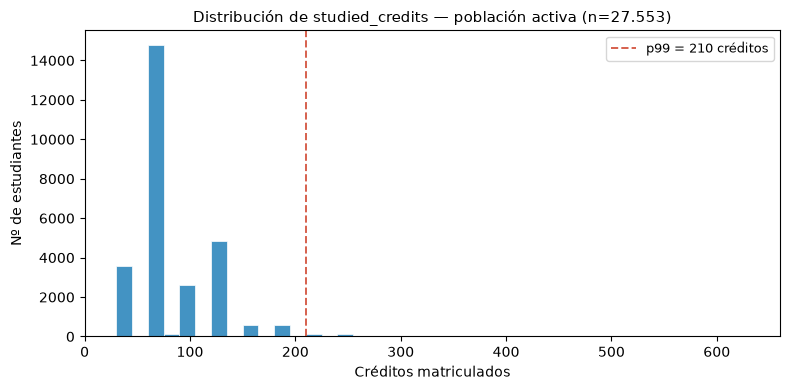

Guardado en ../datos/grafico_studied_credits.png


In [66]:
# Estadísticos de studied_credits (cola alta)
print("studied_credits — estadísticos con percentiles de cola:")
print(df_activos["studied_credits"].describe(percentiles=[.9, .95, .99]))

print("\nFilas con studied_credits > 300 (activos):")
print(df_activos[df_activos["studied_credits"] > 300]
      [["code_module", "code_presentation", "id_student",
        "studied_credits", "num_of_prev_attempts", "final_result"]])

# Histograma de la distribución
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_activos["studied_credits"], bins=40,
        color="#4393c3", edgecolor="white", linewidth=0.5)
p99 = df_activos["studied_credits"].quantile(0.99)
ax.axvline(p99, color="#d6604d", linestyle="--", linewidth=1.4,
           label=f"p99 = {p99:.0f} créditos")
ax.set_xlabel("Créditos matriculados", fontsize=10)
ax.set_ylabel("Nº de estudiantes", fontsize=10)
ax.set_title("Distribución de studied_credits — población activa (n=27.553)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../datos/grafico_studied_credits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en ../datos/grafico_studied_credits.png")

**Comentarios:**

En los 'studied_credits' observamos cómo hay valores raros, extremos que pueden alcanzar los 630 créditos, cuando el 99% de los alumnos se queda en =< 180 créditos simultáneamente. La cola predominante a la derecha en la distribución podemos tomarla como un indicador directo de la carga de trabajo y puede vincularse al riesgo asociado a sobrecargas de trabajo.

### 2.5 Comportamiento en la plataforma (VLE)

Análisis de actividad dentro de la ventana de predicción (días 0–27).

In [67]:
# Filtrar log a ventana de predicción
vle_ventana = student_vle[(student_vle["date"]>=0) &(student_vle["date"] <= 27)].copy()

print(f"Filas en studentVle total:       {len(student_vle):,}")
print(f"Filas en ventana (día 0-27):     {len(vle_ventana):,}")
print(f"Porcentaje del log que usamos:   {len(vle_ventana)/len(student_vle)*100:.1f}%")

# Clics totales por estudiante en la ventana
clics_por_estudiante = vle_ventana.groupby(
    ["id_student", "code_module", "code_presentation"]
)["sum_click"].sum().reset_index()
clics_por_estudiante.columns = ["id_student", "code_module", "code_presentation", "total_clics"]

print(f"\nEstudiantes con actividad en ventana: {len(clics_por_estudiante):,}")
print(f"\nDistribución de clics totales en los 27 primeros días:")
print(clics_por_estudiante["total_clics"].describe(percentiles=[.1,.25,.5,.75,.9,.95]).round(1))

# ¿Hay estudiantes activos en día 27 sin ningún clic registrado?
activos_ids = df_activos[["id_student","code_module","code_presentation"]].copy()
activos_con_clics = activos_ids.merge(clics_por_estudiante, on=["id_student","code_module","code_presentation"], how="left")
sin_actividad = activos_con_clics["total_clics"].isna().sum()
print(f"\nEstudiantes activos en día 27 sin ningún clic registrado: {sin_actividad:,} ({sin_actividad/len(activos_ids)*100:.1f}%)")

Filas en studentVle total:       10,655,280
Filas en ventana (día 0-27):     2,112,323
Porcentaje del log que usamos:   19.8%

Estudiantes con actividad en ventana: 27,886

Distribución de clics totales en los 27 primeros días:
count    27886.0
mean       279.0
std        327.9
min          1.0
10%         24.0
25%         72.0
50%        179.0
75%        370.0
90%        642.5
95%        874.0
max       6084.0
Name: total_clics, dtype: float64

Estudiantes activos en día 27 sin ningún clic registrado: 1,249 (4.5%)


**Comentarios:**

Dentro de nuestra ventana de predicción de 0 a 27 días tenemos el 19,8% del registro total de actividad de los alumnos en la plataforma. Viendo los estadísticos, vemos que hay una distribución asimétrica con una mediana de 179 clics pero una media de 279 y un máximo de 6.084.

En general, viendo los percentiles se observa una varianza enorme, entre el 24 del percentil 10% y 642 del percentil 90%.

Durante nuestro periodo de análisis, también encontramos a 1.249 estudiantes que no tienen registrado ningún clic, esto nos da una pista de que puede ser una clara señal de riesgo = 1, lo confirmaremos en la siguiente celda.

#### Verificación de alumnos con Withdrawn sin fecha de baja y actividad en VLE

In [68]:
# ¿los 93 Withdrawn sin date_unregistration tienen actividad en VLE?
withdrawn_ids = withdrawn_sin_fecha[["code_module", "code_presentation", "id_student"]]
actividad_withdrawn = vle_ventana.merge(
    withdrawn_ids, on=["code_module", "code_presentation", "id_student"], how="inner"
)
n_con_actividad = actividad_withdrawn["id_student"].nunique()
print(f"De los 93 Withdrawn sin fecha de baja, {n_con_actividad} tienen actividad en VLE (días 0-27)")
print(f"-> {n_con_actividad/93*100:.1f}% sí interactuaron con la plataforma")

De los 93 Withdrawn sin fecha de baja, 55 tienen actividad en VLE (días 0-27)
-> 59.1% sí interactuaron con la plataforma


**Comentarios:**

Como ya vimos en el estudio de la tabla studentRegistration, existen 93 alumnos con resultado Withdrawn y sin fecha de baja registrada. De este grupo, vemos ahora que 55 sí interactuaron con la plataforma dentro de la ventana, por lo que no son abandonos silenciosos, sencillamente, participaron activamente pero finalmente no acabaron el módulo.

In [69]:
# ¿Los estudiantes sin actividad son mayoritariamente de riesgo?
activos_con_clics["total_clics"] = activos_con_clics["total_clics"].fillna(0)
activos_con_clics = activos_con_clics.merge(
    df_activos[["id_student","code_module","code_presentation","riesgo"]],
    on=["id_student","code_module","code_presentation"]
)

sin_act = activos_con_clics[activos_con_clics["total_clics"] == 0]
print(f"Riesgo en estudiantes SIN actividad: {sin_act['riesgo'].mean()*100:.1f}%")
print(f"Riesgo en estudiantes CON actividad: {activos_con_clics[activos_con_clics['total_clics']>0]['riesgo'].mean()*100:.1f}%")

# Clics por grupo de riesgo
print("\nEstadísticos de clics por grupo (solo estudiantes con actividad):")
con_act = activos_con_clics[activos_con_clics["total_clics"] > 0]
print(con_act.groupby("riesgo")["total_clics"].describe(
    percentiles=[.25,.5,.75,.9]
).round(1))

Riesgo en estudiantes SIN actividad: 81.4%
Riesgo en estudiantes CON actividad: 42.4%

Estadísticos de clics por grupo (solo estudiantes con actividad):
          count   mean    std  min    25%    50%    75%    90%     max
riesgo                                                                
0       15153.0  344.0  370.2  1.0  107.0  237.0  457.0  760.0  6084.0
1       11151.0  214.7  256.1  1.0   54.0  136.0  283.0  503.0  4114.0


**Comentarios:**

Además de ser la tabla con más información del dataset, ya hemos mencionado también que la actividad en la plataforma es de los predictores más fuertes del modelo. En esta celda vemos como:

- Los 1.249 alumnos sin ningún clic durante los primeros 27 días presentan una tasa de riesgo del 81,4%, es decir, casi 4 de cada 5.
- En el grupo de los estudiantes más activos, los de riesgo = 0 superan en en 130 puntos de media en clics que los de riesgo = 1.
- Las medianas reflejan mejor la tendencia central causada por la asimetría de la distribución 237 clics riesgo = 0 vs 136 clics riesgo = 1.

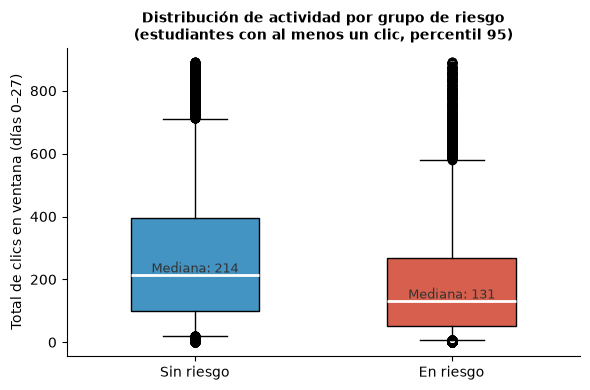

Guardado en ../datos/grafico_clics_boxplot.png


In [70]:
# Separar los dos grupos (solo estudiantes con algún clic)
con_actividad = activos_con_clics[activos_con_clics["total_clics"] > 0].copy()

g0 = con_actividad[con_actividad["riesgo"] == 0]["total_clics"]
g1 = con_actividad[con_actividad["riesgo"] == 1]["total_clics"]

# Recortar en percentil 95 para legibilidad (los outliers extremos aplastan el gráfico)
p95 = con_actividad["total_clics"].quantile(0.95)
g0_clip = g0[g0 <= p95]
g1_clip = g1[g1 <= p95]

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot([g0_clip, g1_clip],
                label=["Sin riesgo", "En riesgo"],
                patch_artist=True,
                widths=0.5,
                whis=(5, 95),                          # <- añadir esto
                medianprops=dict(color='white', linewidth=2))

bp['boxes'][0].set_facecolor('#4393c3')
bp['boxes'][1].set_facecolor('#d6604d')

# Anotar medianas
for i, (grupo, color) in enumerate(zip([g0_clip, g1_clip], ['#4393c3', '#d6604d'])):
    mediana = grupo.median()
    ax.text(i + 1, mediana + 8, f'Mediana: {int(mediana)}',
            ha='center', fontsize=9, color='#333333')

ax.set_xticks([1, 2])
ax.set_xticklabels(["Sin riesgo", "En riesgo"], fontsize=10)
ax.set_ylabel('Total de clics en ventana (días 0–27)', fontsize=10)
ax.set_title('Distribución de actividad por grupo de riesgo\n(estudiantes con al menos un clic, percentil 95)', fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../datos/grafico_clics_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado en ../datos/grafico_clics_boxplot.png")

**Comentarios:**

Pintamos aquí una distribución de clics totales en la ventana por grupo de riesgo (**se acorta en el percentil 95 para facilitar la legibilidad**).

La separación de medianas dentro del P95 es notable (214 frente a 131) pero aún así el solapamiento entre ambos grupos es amplio, habrá que ver cómo combinar esto con otras variables del modelo.

In [71]:
# Actividad por semana (0-6, 7-13, 14-20, 21-27) por grupo de riesgo
vle_ventana["semana"] = (vle_ventana["date"] // 7) + 1

clics_semana = vle_ventana.groupby(
    ["id_student", "code_module", "code_presentation", "semana"]
)["sum_click"].sum().reset_index()

# Unir con riesgo
clics_semana = clics_semana.merge(
    df_activos[["id_student", "code_module", "code_presentation", "riesgo"]],
    on=["id_student", "code_module", "code_presentation"]
)

print("Media de clics por semana y grupo de riesgo:")
pivot = clics_semana.groupby(["semana", "riesgo"])["sum_click"].mean().round(1).unstack()
pivot.columns = ["No riesgo (0)", "Riesgo (1)"]
pivot["ratio No riesgo / Riesgo"] = (pivot["No riesgo (0)"] / pivot["Riesgo (1)"]).round(2)
print(pivot)

Media de clics por semana y grupo de riesgo:
        No riesgo (0)  Riesgo (1)  ratio No riesgo / Riesgo
semana                                                     
1               100.4        67.0                      1.50
2                90.4        61.2                      1.48
3               108.1        82.8                      1.31
4                86.3        59.8                      1.44


**Comentarios**:

A la vista del análisis, existe una diferencia estructural de clics entre grupos, la ratio entre no riesgo y riesgo se mantiene relativamente estable cerca del 1,5 durante toda la ventana y desde las semanas previas al inicio del curso.

Aquí podemos notar una implicación importante para el modelo: no hay un punto crítico de inflexión en el que el grupo de riesgo se diferencie bruscamente del de no riesgo. Los que pertenecen a riesgo = 1 empiezan con menos actividad desde el principio, de modo que el total acumulado de clics es mejor predictor que la pendiente o el cambio semanal.

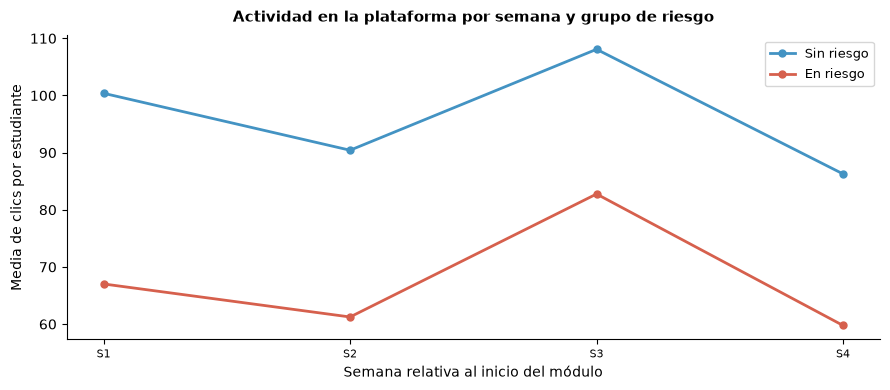

Guardado en ../datos/grafico_actividad_vle.png


In [72]:
# clics_semana ya calculado arriba - solo ventana 0-27 (semanas 1 a 4)
media_semana = clics_semana.groupby(["semana", "riesgo"])["sum_click"].mean().reset_index()
media_semana["grupo"] = media_semana["riesgo"].map({0: "Sin riesgo", 1: "En riesgo"})

semanas_orden = sorted(media_semana["semana"].unique())

fig, ax = plt.subplots(figsize=(9, 4))

colores = {0: "#4393c3", 1: "#d6604d"}
for grupo in [0, 1]:
    datos = media_semana[media_semana["riesgo"] == grupo].sort_values("semana")
    ax.plot(datos["semana"], datos["sum_click"],
            marker='o', linewidth=2, markersize=5,
            color=colores[grupo],
            label="Sin riesgo" if grupo == 0 else "En riesgo")

ax.set_xlabel('Semana relativa al inicio del módulo', fontsize=10)
ax.set_ylabel('Media de clics por estudiante', fontsize=10)
ax.set_title('Actividad en la plataforma por semana y grupo de riesgo', fontsize=11, fontweight='bold', pad=10)
ax.set_xticks(semanas_orden)
ax.set_xticklabels([f'S{int(s)}' for s in semanas_orden], fontsize=8)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../datos/grafico_actividad_vle.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado en ../datos/grafico_actividad_vle.png")

**Comentarios:**

Presentamos una gráfica de evolución de la media de clics por semana para cada grupo dentro de la ventana de predicción. 

A pesar de las diferencias numéricas las líneas nos muestran los mismos patrones de oscilación durante todo el periodo, los estudiantes de ambos grupos tienen comportamientos parejos, es decir, decrecen su actividad entre la primera y la segunda semana, sube de la segunda a la tercera (siendo este punto donde se estrecha más la ratio de riesgo) y vuelve a caer entre la tercera y la cuarta.

### 2.6 Evaluaciones en ventana

Solo TMA/CMA con 'date_submitted =<27` y 'is_banked = 0'. EEE y GGG no tienen evaluaciones en la ventana — sus features de assessment serán 0/NaN en H2.

In [73]:
# Unir student_assess con assessments para tener tipo y fecha límite
assess_completo = student_assess.merge(
    assessments[["id_assessment", "code_module", "code_presentation", 
                 "assessment_type", "date", "weight"]],
    on="id_assessment"
)

print("Tipos de evaluación en el dataset completo:")
print(assess_completo["assessment_type"].value_counts())

# ¿Qué evaluaciones tienen fecha límite dentro de nuestra ventana (día <= 27)?
print("\nEvaluaciones con fecha límite <= día 27 (por tipo):")
en_ventana = assess_completo[assess_completo["date"] <= 27]
print(en_ventana["assessment_type"].value_counts())

print(f"\nTotal entregas en ventana (date_submitted <= 27): {(assess_completo['date_submitted'] <= 27).sum():,}")
print(f"Total entregas fuera de ventana:                  {(assess_completo['date_submitted'] > 27).sum():,}")

# ¿Hay exámenes finales dentro de los primeros 27 días?
examenes_ventana = en_ventana[en_ventana["assessment_type"] == "Exam"]
print(f"\nExámenes finales con fecha <= 27: {len(examenes_ventana):,}")

Tipos de evaluación en el dataset completo:
assessment_type
TMA     98426
CMA     70527
Exam     4959
Name: count, dtype: int64

Evaluaciones con fecha límite <= día 27 (por tipo):
assessment_type
TMA    17770
CMA     4273
Name: count, dtype: int64

Total entregas en ventana (date_submitted <= 27): 25,348
Total entregas fuera de ventana:                  148,564

Exámenes finales con fecha <= 27: 0


**Comentarios:**

Recuperamos aquí los tipos de entregas del dataset, que en la tabla ya vimos que eran tres, si bien tan solo TMA y CMA podían caer, por lógica, dentro de la ventana de predicción, ya que el examen final no tendría sentido que estuviera dentro de las 4 primeras semanas en un módulo que dura varios meses.

Ante esto, tenemos que el número de entregas dentro de la ventana asciende a 25.348, lo que equivale al 14,6% del total.

In [74]:
# Evaluaciones en ventana: filtros, diagnóstico y tasa de entrega
# ---------------------------------------------------------------
# Decisiones aplicadas:
#   - date_submitted <= 27: solo entregas dentro de la ventana
#   - is_banked = 0: excluir entregas importadas de presentaciones anteriores
#   - Tipos TMA/CMA: los exámenes nunca caen en la ventana (verificado en EDA)
#   - Denominador correcto: solo módulos con evaluación ≤ día 27 (EEE y GGG excluidos)

# 1. ¿Qué módulos tienen evaluaciones con deadline dentro de la ventana?
assess_en_ventana_distintas = assessments[assessments["date"] <= 27]
modulos_con_eval = assess_en_ventana_distintas["code_module"].unique()

print(f"Evaluaciones distintas con deadline <= día 27: {len(assess_en_ventana_distintas)}")
print(assess_en_ventana_distintas[["code_module", "code_presentation", "assessment_type", "date"]]
      .sort_values(["code_module", "date"]).to_string(index=False))

print(f"\nMódulos CON evaluación en primeros 27 días: {sorted(modulos_con_eval)}")
print(f"Módulos SIN evaluación en primeros 27 días: "
      f"{sorted(set(df_activos['code_module'].unique()) - set(modulos_con_eval))}")

# 2. Definir assess_ventana (filtrado correcto)
assess_ventana = assess_completo[
    (assess_completo["date_submitted"] <= 27) &
    (assess_completo["is_banked"] == 0) &
    (assess_completo["assessment_type"].isin(["TMA", "CMA"]))
].copy()

n_importadas_excluidas = assess_completo[
    (assess_completo["date_submitted"] <= 27) &
    (assess_completo["is_banked"] == 1)
].shape[0]

print(f"\nEntregas en ventana (is_banked=0, TMA/CMA): {len(assess_ventana):,}")
print(f"Entregas importadas excluidas:                  {n_importadas_excluidas:,}")
print(f"Rango date_submitted: {assess_ventana['date_submitted'].min()} → {assess_ventana['date_submitted'].max()}")

# 3. Agregar métricas por estudiante
entregaron = assess_ventana.groupby(
    ["id_student", "code_module", "code_presentation"]
).agg(
    n_entregas=("id_assessment", "count"),
    nota_media=("score", "mean"),
    nota_min=("score", "min")
).reset_index().merge(
    df_activos[["id_student", "code_module", "code_presentation", "riesgo"]],
    on=["id_student", "code_module", "code_presentation"]
)

# 4. Tasa de entrega — denominador correcto: módulos con eval en ventana
df_con_eval = df_activos[df_activos["code_module"].isin(modulos_con_eval)].copy()
df_con_eval["entrego"] = df_con_eval[
    ["id_student", "code_module", "code_presentation"]
].apply(tuple, axis=1).isin(
    entregaron[["id_student", "code_module", "code_presentation"]].apply(tuple, axis=1)
).astype(int)

print(f"\nEstudiantes en módulos con evaluación temprana: {len(df_con_eval):,}")
print("\nTasa de entrega por grupo de riesgo (denominador correcto):")
print(df_con_eval.groupby("riesgo")["entrego"].mean().mul(100).round(1))

print("\nMétricas de nota en entregas tempranas por grupo de riesgo:")
print(entregaron.groupby("riesgo")[["n_entregas", "nota_media", "nota_min"]].mean().round(2))

Evaluaciones distintas con deadline <= día 27: 17
code_module code_presentation assessment_type  date
        AAA             2013J             TMA  19.0
        AAA             2014J             TMA  19.0
        BBB             2014B             TMA  12.0
        BBB             2013B             TMA  19.0
        BBB             2013J             TMA  19.0
        BBB             2014J             TMA  19.0
        CCC             2014B             CMA  18.0
        CCC             2014J             CMA  18.0
        DDD             2014J             TMA  20.0
        DDD             2013B             CMA  23.0
        DDD             2013B             TMA  25.0
        DDD             2013J             TMA  25.0
        DDD             2014B             TMA  25.0
        FFF             2013B             TMA  19.0
        FFF             2013J             TMA  19.0
        FFF             2014B             TMA  24.0
        FFF             2014J             TMA  24.0

Módulos CON e

**Comentarios:**

Hay un hándicap que ya se ha comentado en la tabla de entregas y es que hay dos módulos que no tienen evaluación alguna dentro de los 27 primeros días, eso supone que para los 5.468 alumnos activos de dichos cursos, el modelo tendrá que predecir únicamente con la actividad de la plataforma y las variables demográficas, sin apoyos de evaluaciones.

En cuanto al resto de módulos:

- La tasa de entrega entre grupos de riesgo tiene una diferencia de 21 puntos porcentuales, convirtiendo el hecho de no haber entregado en ese periodo inicial en un potente predictor de riesgo.
- En cuanto a las notas obtenidas, también hay diferencia aunque en este caso se queda en 11 puntos porcentuales, pero viendo el solapamiento el indicador es claro: existen casos de estudiantes con buenas notas que acaban abandonando y viceversa.